In [38]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import statsmodels.api as sm

# ---------------------------------
# Read data
# ---------------------------------

counts = pd.read_csv("CTR_Juvenile_ASD_Master.csv")
lengths = pd.read_csv("Juvenile_Master_Length_Data_1978_2021.csv")

# ---------------------------------
# Define study months and site groups
# ---------------------------------

study_months = [7, 8, 9]

upper_sites = ["HOLYOKE", "ENFIELD", "WILSON"]

lower_sites = [
    "GLASTONBURY",
    "DEEP RIVER",
    "SALMON RIVER",
    "ESSEX"
]

# ---------------------------------
# Clean counts data
# ---------------------------------

counts["ASD_Count"] = pd.to_numeric(counts["ASD_Count"], errors="coerce")
counts["Temp"] = pd.to_numeric(counts["Temp"], errors="coerce")
counts["Month"] = pd.to_numeric(counts["Month"], errors="coerce")

counts["Site"] = (
    counts["Site"]
    .astype(str)
    .str.upper()
    .str.strip()
)

counts = counts[counts["Month"].isin(study_months)].copy()

# ---------------------------------
# Clean lengths data
# ---------------------------------

lengths["Length"] = pd.to_numeric(lengths["Length"], errors="coerce")
lengths["Month"] = pd.to_numeric(lengths["Month"], errors="coerce")
lengths["Date"] = pd.to_datetime(lengths["Date"], errors="coerce")
lengths["DOY"] = lengths["Date"].dt.dayofyear

lengths["Site"] = (
    lengths["Site"]
    .astype(str)
    .str.upper()
    .str.strip()
)

lengths = lengths[lengths["Month"].isin(study_months)].copy()

# 1. GM+1 index for All sites, Upper river and Lower river

In [39]:
# ---------------------------------
# Geometric mean (+1 transformation)
# ---------------------------------

def gm_plus1(x):
    
    # Compute the geometric mean index using log(x + 1). The +1 prevents problems with zero counts.
    # This method is commonly used for abundance data.

    x = np.asarray(x)

    return np.exp(np.mean(np.log(x + 1))) - 1

In [40]:
# ---------------------------------
# Annual GM+1 abundance index
# ---------------------------------

def annual_gm_index(data, min_samples=1):
    # Compute the annual GM+1 abundance index.
    
    # Remove rows with missing abundance values
    data = data.dropna(subset=["ASD_Count"]).copy()

    # Compute annual summaries
    result = (
        data.groupby("Year")
        .agg(
            GM_Index=("ASD_Count", gm_plus1),
            N_samples=("ASD_Count", "count")
        )
        .reset_index()
        .sort_values("Year")
    )

    # Keep only years with sufficient sampling
    result = result[result["N_samples"] >= min_samples]

    return result

In [41]:
# ---------------------------------
# GM+1 abundance indices
# ---------------------------------
# Require at least 10 observations per year to improve stability of annual estimates

# Entire river
gm_all = annual_gm_index(counts, min_samples=10)

print("\nGM+1 index — ALL sites")
print(gm_all)

# Upper river
counts_upper = counts[counts["Site"].isin(upper_sites)].copy()

gm_upper = annual_gm_index(
    counts_upper,
    min_samples=10
)

print("\nGM+1 index — UPPER river")
print(gm_upper)

# Lower river
counts_lower = counts[counts["Site"].isin(lower_sites)].copy()

gm_lower = annual_gm_index(
    counts_lower,
    min_samples=10
)

print("\nGM+1 index — LOWER river")
print(gm_lower)


GM+1 index — ALL sites
    Year   GM_Index  N_samples
0   1978   7.932691         52
1   1979   8.362842         54
2   1980  10.172562         60
3   1981   7.233661         77
4   1982   1.923998         71
5   1983   5.028478         75
6   1984   4.117481         59
7   1985   7.381639         65
8   1986   6.316636         83
9   1987  12.981780         83
10  1988   5.905538         83
11  1989   5.151229         84
12  1990  12.768370         76
13  1991   4.186679         83
14  1992   9.216513         83
15  1993  10.120233         83
16  1994  16.411348         84
17  1995   1.414481         83
18  1996   7.326029         75
19  1997   7.541097         84
20  1998   4.277790         84
21  1999   5.525662         82
22  2000   5.126225         84
23  2001   2.836393         76
24  2002   5.622409         77
25  2003   6.980184         70
26  2004   6.383257         83
27  2005  10.727468         80
28  2006   1.980945         82
29  2007   8.249329         76
30  2008   6.25

#  Statistical comparison between regions


   Year  GM_Index_Upper  N_samples_Upper  GM_Index_Lower  N_samples_Lower
0  1978        6.882842               22        8.790432               30
1  1979        7.620001               22        8.910355               32
2  1980       22.960195               20        6.629287               40
3  1981        7.788934               33        6.840352               44
4  1982        1.321435               31        2.496617               40

Summary of annual differences (Upper - Lower)
count     45.000000
mean       9.203957
std       25.290143
min       -9.697892
25%       -1.329065
50%        4.500208
75%        9.599904
max      152.018621
Name: Difference, dtype: float64

Mean annual difference = 9.203956596956722

Paired t-test: Upper vs Lower river GM+1 index
t = 2.4413471476989197
p = 0.018723816222141053

Result: Significant difference between regions.
Upper river indices tend to be higher.


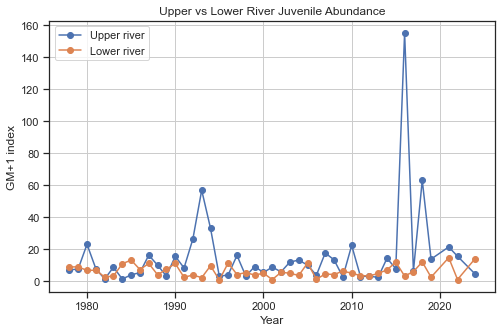

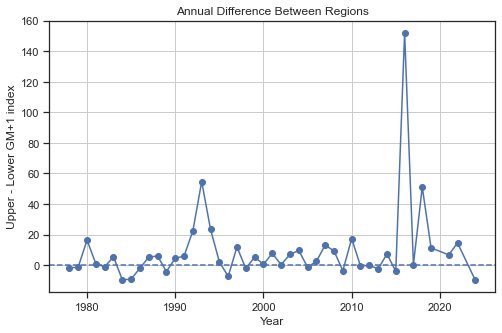

In [42]:
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# ---------------------------------
# Compare upper and lower river
# GM+1 abundance indices
# ---------------------------------

# Merge annual indices by year
gm_compare = pd.merge(
    gm_upper,
    gm_lower,
    on="Year",
    suffixes=("_Upper", "_Lower")
)

print(gm_compare.head())

# ---------------------------------
# Compute annual differences
# ---------------------------------

gm_compare["Difference"] = (
    gm_compare["GM_Index_Upper"]
    - gm_compare["GM_Index_Lower"]
)

print("\nSummary of annual differences (Upper - Lower)")
print(gm_compare["Difference"].describe())

mean_difference = gm_compare["Difference"].mean()

print("\nMean annual difference =", mean_difference)

# ---------------------------------
# Paired t-test
# ---------------------------------

t_stat, p_value = ttest_rel(
    gm_compare["GM_Index_Upper"],
    gm_compare["GM_Index_Lower"]
)

print("\nPaired t-test: Upper vs Lower river GM+1 index")
print("t =", t_stat)
print("p =", p_value)

# ---------------------------------
# Interpretation
# ---------------------------------

if p_value < 0.05:
    print("\nResult: Significant difference between regions.")

    if mean_difference > 0:
        print("Upper river indices tend to be higher.")
    else:
        print("Lower river indices tend to be higher.")

else:
    print("\nResult: No statistically significant difference detected.")

# ---------------------------------
# Plot annual GM+1 indices
# ---------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    gm_compare["Year"],
    gm_compare["GM_Index_Upper"],
    marker="o",
    label="Upper river"
)

plt.plot(
    gm_compare["Year"],
    gm_compare["GM_Index_Lower"],
    marker="o",
    label="Lower river"
)

plt.xlabel("Year")
plt.ylabel("GM+1 index")
plt.title("Upper vs Lower River Juvenile Abundance")
plt.legend()
plt.grid(True)

plt.show()

# ---------------------------------
# Plot annual differences
# ---------------------------------

plt.figure(figsize=(8, 5))

plt.axhline(0, linestyle="--")

plt.plot(
    gm_compare["Year"],
    gm_compare["Difference"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Upper - Lower GM+1 index")
plt.title("Annual Difference Between Regions")
plt.grid(True)

plt.show()

In [43]:
from scipy.stats import wilcoxon

# ---------------------------------
# Wilcoxon signed-rank test
# ---------------------------------

w_stat, w_p = wilcoxon(
    gm_compare["GM_Index_Upper"],
    gm_compare["GM_Index_Lower"]
)

print("\nWilcoxon signed-rank test")
print("W =", w_stat)
print("p =", w_p)


Wilcoxon signed-rank test
W = 252.0
p = 0.002727893987947713


## Diagnostic examination of selected years

In [44]:
def site_contribution_for_year(data, year):
    # Examine how individual sites contribute to total abundance in a selected year.

    print("\nYear:", year)

    d = data[data["Year"] == year].copy()

    if d.empty:
        print("No data available for this year.")
        return None

    print("N =", len(d))
    print("Max count =", d["ASD_Count"].max())
    print("Mean count =", d["ASD_Count"].mean())
    print("Median count =", d["ASD_Count"].median())

    print("\nTop counts:")
    print(
        d.sort_values("ASD_Count", ascending=False)
         .head(10)
    )

    site_totals = (
        d.groupby("Site")["ASD_Count"]
        .sum()
        .sort_values(ascending=False)
    )

    percent = 100 * site_totals / site_totals.sum()

    result = pd.DataFrame({
        "Total_Count": site_totals,
        "Percent_of_total": percent
    })

    print("\nSite contribution:")
    print(result)

    return result


# Look at selected years
site_contribution_for_year(counts_upper, 2016)
site_contribution_for_year(counts_upper, 2018)


Year: 2016
N = 36
Max count = 3744
Mean count = 631.4722222222222
Median count = 284.5

Top counts:
      Year  Month  Day        Date     Site  SiteNum  ASD_Count  Temp Code  \
3548  2016      8   24  2016-08-24  HOLYOKE        1       3744  25.0    S   
3555  2016      9    1  2016-09-01  HOLYOKE        1       2984  24.0    S   
3529  2016      8    3  2016-08-03  HOLYOKE        1       2571  26.0    C   
3510  2016      7   13  2016-07-13   WILSON        3       1596  26.0    C   
3534  2016      8   10  2016-08-10  HOLYOKE        1       1415  25.0    C   
3515  2016      7   20  2016-07-20  HOLYOKE        1       1189  26.0    C   
3522  2016      7   27  2016-07-27  HOLYOKE        1       1071  27.0    C   
3564  2016      9    7  2016-09-07   WILSON        3        927  23.0    C   
3578  2016      9   21  2016-09-21   WILSON        3        790  23.0    C   
3562  2016      9    7  2016-09-07  HOLYOKE        1        711  22.0    C   

        Source  
3548  Detailed  
3555  

,Total_Count,Percent_of_total
Site,,
HOLYOKE,5436,72.470337
ENFIELD,1136,15.144647
WILSON,929,12.385015


# 2. Mean Temperature for All sites, Upper river and Lower river

In [45]:
# ---------------------------------
# Annual mean temperature
# ---------------------------------

def annual_mean_temperature(data, min_samples=1):
    # Compute annual mean temperature.

    # Remove missing temperature values
    data = data.dropna(subset=["Temp"]).copy()

    # Compute annual summaries
    result = (
        data.groupby("Year")
        .agg(
            Mean_Temp=("Temp", "mean"),
            Temp_samples=("Temp", "count")
        )
        .reset_index()
        .sort_values("Year")
    )

    # Keep only years with sufficient sampling
    result = result[result["Temp_samples"] >= min_samples]

    return result

In [46]:
# ---------------------------------
# Annual mean temperature by region
# ---------------------------------

# Entire river
temp_all = annual_mean_temperature(counts)

print("\nAnnual mean temperature — ALL sites")
print(temp_all)

# Upper river
temp_upper = annual_mean_temperature(counts_upper)

print("\nAnnual mean temperature — UPPER river")
print(temp_upper)

# Lower river
temp_lower = annual_mean_temperature(counts_lower)

print("\nAnnual mean temperature — LOWER river")
print(temp_lower)


Annual mean temperature — ALL sites
    Year  Mean_Temp  Temp_samples
0   1983  25.280000            75
1   1985  24.715385            65
2   1986  22.790123            81
3   1987  23.349398            83
4   1988  25.108434            83
5   1989  24.047619            84
6   1990  23.407895            76
7   1991  23.722892            83
8   1992  23.445783            83
9   1993  25.105263            76
10  1994  23.880952            84
11  1995  25.043478            69
12  1996  22.867647            68
13  1997  24.750000            84
14  1998  25.194805            77
15  1999  24.560976            82
16  2000  22.535714            84
17  2001  24.907895            76
18  2002  25.376623            77
19  2003  23.728571            70
20  2004  21.566265            83
21  2005  23.462500            80
22  2006  24.675325            77
23  2007  25.381579            76
24  2008  23.865672            67
25  2009  23.171053            76
26  2010  25.377778            90
27  2011  2


Summary of annual temperature differences (Upper - Lower)
count    39.000000
mean     -1.655331
std       0.484327
min      -2.504065
25%      -2.003892
50%      -1.659091
75%      -1.407640
max      -0.011310
Name: Difference, dtype: float64

Paired t-test: Upper vs Lower annual mean temperature
t = -21.34414833371946
p = 9.287616744577981e-23

Wilcoxon signed-rank test
W = 0.0
p = 5.253340807676992e-08


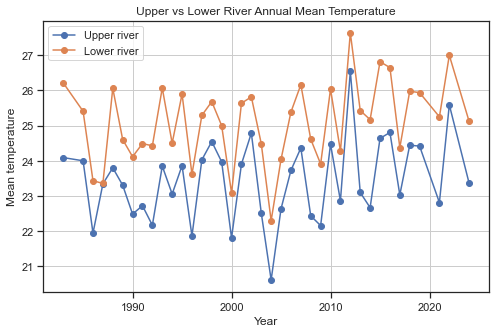

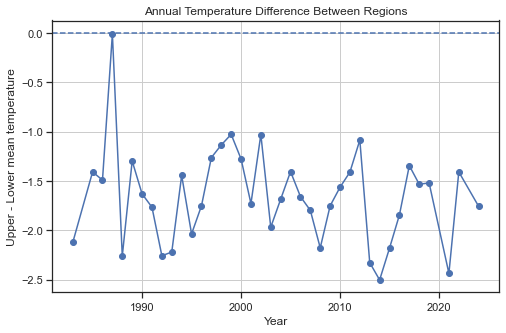

In [47]:
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt

# ---------------------------------
# Compare upper and lower river annual mean temperature
# ---------------------------------

temp_compare = pd.merge(
    temp_upper,
    temp_lower,
    on="Year",
    suffixes=("_Upper", "_Lower")
)

temp_compare["Difference"] = (
    temp_compare["Mean_Temp_Upper"]
    - temp_compare["Mean_Temp_Lower"]
)

print("\nSummary of annual temperature differences (Upper - Lower)")
print(temp_compare["Difference"].describe())

# Paired t-test
t_stat, p_value = ttest_rel(
    temp_compare["Mean_Temp_Upper"],
    temp_compare["Mean_Temp_Lower"]
)

print("\nPaired t-test: Upper vs Lower annual mean temperature")
print("t =", t_stat)
print("p =", p_value)

# Wilcoxon signed-rank test
w_stat, w_p = wilcoxon(
    temp_compare["Mean_Temp_Upper"],
    temp_compare["Mean_Temp_Lower"]
)

print("\nWilcoxon signed-rank test")
print("W =", w_stat)
print("p =", w_p)

# Plot annual mean temperature
plt.figure(figsize=(8, 5))

plt.plot(
    temp_compare["Year"],
    temp_compare["Mean_Temp_Upper"],
    marker="o",
    label="Upper river"
)

plt.plot(
    temp_compare["Year"],
    temp_compare["Mean_Temp_Lower"],
    marker="o",
    label="Lower river"
)

plt.xlabel("Year")
plt.ylabel("Mean temperature")
plt.title("Upper vs Lower River Annual Mean Temperature")
plt.legend()
plt.grid(True)

plt.show()

# Plot annual differences
plt.figure(figsize=(8, 5))

plt.axhline(0, linestyle="--")

plt.plot(
    temp_compare["Year"],
    temp_compare["Difference"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Upper - Lower mean temperature")
plt.title("Annual Temperature Difference Between Regions")
plt.grid(True)

plt.show()

# 3. Growth rate for All sites, Upper river and Lower river

In [48]:
# ---------------------------------
# Compute annual growth rates
# ---------------------------------

def compute_growth(data, min_samples=30, min_doy=10):
    # Estimate annual juvenile growth rates using linear regression.

    # Remove rows with missing values
    data = data.dropna(subset=["Length", "DOY"]).copy()

    records = []

    # Analyze each year separately
    for year, dy in data.groupby("Year"):

        # Require sufficient sample size and temporal coverage
        if (
            len(dy) >= min_samples
            and dy["DOY"].nunique() >= min_doy
        ):

            fit = linregress(
                dy["DOY"],
                dy["Length"]
            )

            records.append({
                "Year": year,
                "Growth_mm_per_day": fit.slope,
                "N_growth": len(dy),
                "N_DOY": dy["DOY"].nunique(),
                "Intercept": fit.intercept,
                "R_value": fit.rvalue,
                "P_value": fit.pvalue
            })

    return (
        pd.DataFrame(records)
        .sort_values("Year")
        .reset_index(drop=True)
    )

In [49]:
# ---------------------------------
# Annual growth rates: all sites
# ---------------------------------

growth_all = compute_growth(lengths)

print("\nGrowth — ALL sites")
print(growth_all)


Growth — ALL sites
    Year  Growth_mm_per_day  N_growth  N_DOY  Intercept   R_value  \
0   1979           0.394735       666     11 -30.368627  0.685678   
1   1980           0.304794       983     10   1.755373  0.551786   
2   1981           0.320810       987     11  -6.795122  0.673212   
3   1982           0.575138       351     11 -65.472370  0.808533   
4   1984           0.601677       563     10 -80.944085  0.822458   
5   1986           0.296179      1086     13  -4.737564  0.497479   
6   1987           0.486561      1343     12 -44.129070  0.743246   
7   1988           0.435776       906     12 -33.712279  0.727599   
8   1989           0.551059       867     12 -63.570931  0.622328   
9   1990           0.356238      1449     12 -26.686566  0.596542   
10  1991           0.413372       860     12 -18.404202  0.659731   
11  1992           0.391460      1272     13 -25.563084  0.636504   
12  1993           0.410719      1392     13 -29.692106  0.776150   
13  1994      

In [50]:
# ---------------------------------
# Annual growth rates: upper river
# ---------------------------------

lengths_upper = (
    lengths[lengths["Site"].isin(upper_sites)]
    .copy()
)

growth_upper = compute_growth(lengths_upper)

print("\nGrowth — UPPER river")
print(growth_upper)


Growth — UPPER river
    Year  Growth_mm_per_day  N_growth  N_DOY   Intercept   R_value  \
0   1979           0.387962       282     11  -30.072103  0.721769   
1   1980           0.378200       488     10  -17.126235  0.670595   
2   1981           0.341176       448     11  -14.445739  0.668822   
3   1982           0.544894       141     10  -61.411810  0.790861   
4   1986           0.315561       427     13  -11.037821  0.514023   
5   1987           0.529575       574     12  -55.452307  0.803333   
6   1988           0.482495       525     12  -47.847193  0.830867   
7   1989           0.363813       261     10  -25.142812  0.454392   
8   1990           0.303829       714     12  -17.016661  0.536914   
9   1991           0.507747       608     10  -38.839384  0.672006   
10  1992           0.494962       904     13  -52.234788  0.772891   
11  1993           0.421898      1137     13  -33.170358  0.786664   
12  1994           0.426710       830     12  -34.269177  0.744803  

In [51]:
# ---------------------------------
# Annual growth rates: lower river
# ---------------------------------

lengths_lower = (
    lengths[lengths["Site"].isin(lower_sites)]
    .copy()
)

growth_lower = compute_growth(lengths_lower)

print("\nGrowth — LOWER river")
print(growth_lower)


Growth — LOWER river
    Year  Growth_mm_per_day  N_growth  N_DOY   Intercept   R_value  \
0   1979           0.394476       384     11  -29.369289  0.667289   
1   1980           0.279169       495     10    9.040378  0.496047   
2   1981           0.294656       539     11    1.839557  0.698959   
3   1982           0.564837       210     10  -61.241369  0.812173   
4   1984           0.596170       428     10  -80.022394  0.804967   
5   1986           0.273878       659     13    1.643211  0.480047   
6   1987           0.442438       769     12  -32.634525  0.687848   
7   1988           0.307467       381     12    1.091237  0.545923   
8   1989           0.564253       606     12  -65.426297  0.615466   
9   1990           0.312623       735     12  -14.266372  0.495870   
10  1991           0.155129       252     12   45.084851  0.277411   
11  1992           0.260808       368     13   10.395270  0.477941   
12  1993           0.320471       255     13   -3.757173  0.705886  


Summary of annual growth differences (Upper - Lower)
count    33.000000
mean      0.072314
std       0.125057
min      -0.224225
25%       0.005471
50%       0.083182
75%       0.150839
max       0.352618
Name: Difference, dtype: float64

Paired t-test
t = 3.321761408002073
p = 0.0022458292383855842

Wilcoxon signed-rank test
W = 109.0
p = 0.0021815615385407695


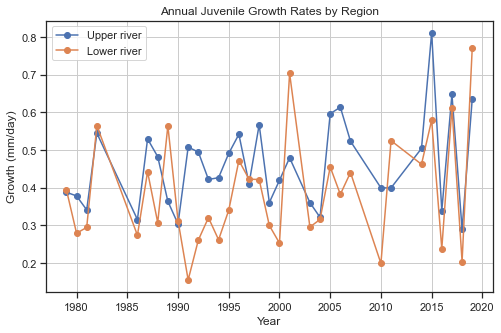

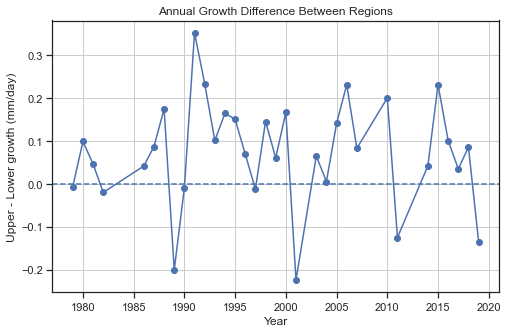

In [52]:
# ---------------------------------
# Compare upper and lower river annual growth rates
# ---------------------------------

growth_compare = pd.merge(
    growth_upper,
    growth_lower,
    on="Year",
    suffixes=("_Upper", "_Lower")
)

# Compute annual differences
growth_compare["Difference"] = (
    growth_compare["Growth_mm_per_day_Upper"]
    - growth_compare["Growth_mm_per_day_Lower"]
)

print("\nSummary of annual growth differences (Upper - Lower)")
print(growth_compare["Difference"].describe())

# ---------------------------------
# Paired t-test
# ---------------------------------

t_stat, p_value = ttest_rel(
    growth_compare["Growth_mm_per_day_Upper"],
    growth_compare["Growth_mm_per_day_Lower"]
)

print("\nPaired t-test")
print("t =", t_stat)
print("p =", p_value)

# ---------------------------------
# Wilcoxon signed-rank test
# ---------------------------------

w_stat, w_p = wilcoxon(
    growth_compare["Growth_mm_per_day_Upper"],
    growth_compare["Growth_mm_per_day_Lower"]
)

print("\nWilcoxon signed-rank test")
print("W =", w_stat)
print("p =", w_p)

# ---------------------------------
# Plot annual growth rates
# ---------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    growth_compare["Year"],
    growth_compare["Growth_mm_per_day_Upper"],
    marker="o",
    label="Upper river"
)

plt.plot(
    growth_compare["Year"],
    growth_compare["Growth_mm_per_day_Lower"],
    marker="o",
    label="Lower river"
)

plt.xlabel("Year")
plt.ylabel("Growth (mm/day)")
plt.title("Annual Juvenile Growth Rates by Region")

plt.legend()
plt.grid(True)

plt.show()

# ---------------------------------
# Plot annual differences
# ---------------------------------

plt.figure(figsize=(8, 5))

plt.axhline(0, linestyle="--")

plt.plot(
    growth_compare["Year"],
    growth_compare["Difference"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Upper - Lower growth (mm/day)")
plt.title("Annual Growth Difference Between Regions")

plt.grid(True)

plt.show()

# 4. Regression: Growth rate vs Index or MeanTemp or both (All sites)


Merged dataset — ALL sites
 Year  Growth_mm_per_day  GM_Index  Mean_Temp
 1986           0.296179  6.316636  22.790123
 1987           0.486561 12.981780  23.349398
 1988           0.435776  5.905538  25.108434
 1989           0.551059  5.151229  24.047619
 1990           0.356238 12.768370  23.407895
 1991           0.413372  4.186679  23.722892
 1992           0.391460  9.216513  23.445783
 1993           0.410719 10.120233  25.105263
 1994           0.373295 16.411348  23.880952
 1995           0.473767  1.414481  25.043478
 1996           0.504794  7.326029  22.867647
 1997           0.423248  7.541097  24.750000
 1998           0.485604  4.277790  25.194805
 1999           0.360323  5.525662  24.560976
 2000           0.320201  5.126225  22.535714
 2001           0.557914  2.836393  24.907895
 2002           0.489575  5.622409  25.376623
 2003           0.351604  6.980184  23.728571
 2004           0.328989  6.383257  21.566265
 2005           0.524954 10.727468  23.462500
 2006 

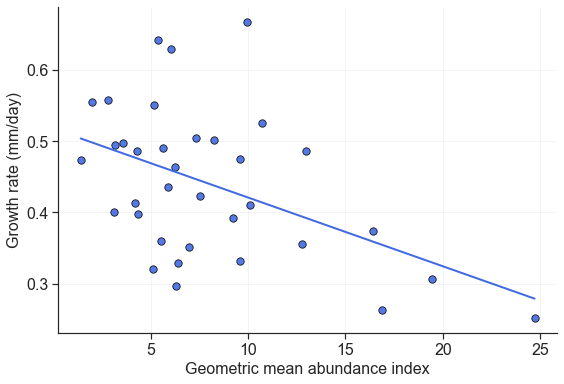

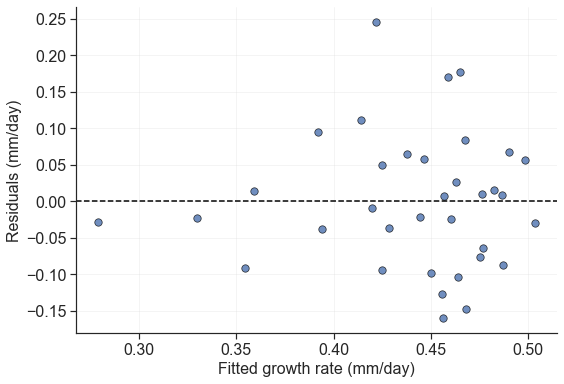

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


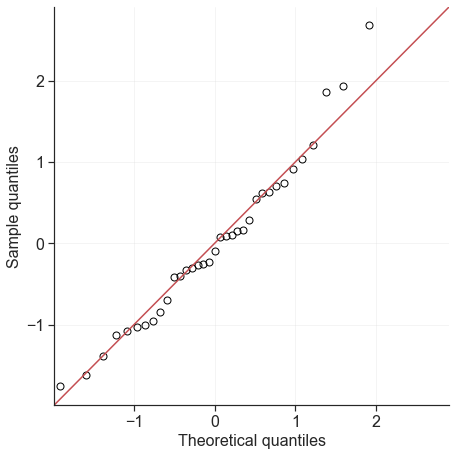

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import linregress


# ============================================================
# MERGE DATA — ALL SITES
# ============================================================

growth_abundance_all = (
    growth_all
    .merge(
        gm_all[["Year", "GM_Index"]],
        on="Year",
        how="inner"
    )
    .merge(
        temp_all[["Year", "Mean_Temp"]],
        on="Year",
        how="inner"
    )
    .sort_values("Year")
    .reset_index(drop=True)
)

print("\nMerged dataset — ALL sites")

print(
    growth_abundance_all[
        [
            "Year",
            "Growth_mm_per_day",
            "GM_Index",
            "Mean_Temp"
        ]
    ].to_string(index=False)
)

print(
    "\nNumber of years:",
    len(growth_abundance_all)
)


# ============================================================
# SIMPLE LINEAR REGRESSION
# GROWTH VS. ABUNDANCE
# ============================================================

fit_all = linregress(
    growth_abundance_all["GM_Index"],
    growth_abundance_all["Growth_mm_per_day"]
)

print("\nSimple linear regression — ALL sites")
print("Slope:", fit_all.slope)
print("Intercept:", fit_all.intercept)
print("R-squared:", fit_all.rvalue**2)
print("p-value:", fit_all.pvalue)
print("Standard error:", fit_all.stderr)


# ============================================================
# FITTED VALUES AND RESIDUALS
# ============================================================

growth_abundance_all["Predicted"] = (
    fit_all.intercept
    + fit_all.slope
    * growth_abundance_all["GM_Index"]
)

growth_abundance_all["Residual"] = (
    growth_abundance_all["Growth_mm_per_day"]
    - growth_abundance_all["Predicted"]
)

print("\nResidual summary")

print(
    growth_abundance_all["Residual"]
    .describe()
)


# ============================================================
# PUBLICATION SETTINGS
# ============================================================

label_size = 16
tick_size = 16
marker_size = 55

sns.set_theme(style="ticks")


# ============================================================
# GROWTH VERSUS ABUNDANCE
# ============================================================

x = growth_abundance_all["GM_Index"]
y = growth_abundance_all["Growth_mm_per_day"]

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = (
    fit_all.intercept
    + fit_all.slope * x_line
)

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.scatter(
    x,
    y,
    s=marker_size,
    color="royalblue",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)

ax.plot(
    x_line,
    y_line,
    color="royalblue",
    linewidth=2
)

ax.set_xlabel(
    "Geometric mean abundance index",
    fontsize=label_size
)

ax.set_ylabel(
    "Growth rate (mm/day)",
    fontsize=label_size
)

ax.tick_params(
    axis="both",
    labelsize=tick_size,
    width=1.2,
    length=6
)

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.8
)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

sns.despine(ax=ax)

fig.tight_layout()

fig.savefig(
    "growth_abundance_all.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# RESIDUALS VERSUS FITTED VALUES
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.scatter(
    growth_abundance_all["Predicted"],
    growth_abundance_all["Residual"],
    s=marker_size,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.8
)

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel(
    "Fitted growth rate (mm/day)",
    fontsize=label_size
)

ax.set_ylabel(
    "Residuals (mm/day)",
    fontsize=label_size
)

ax.tick_params(
    axis="both",
    labelsize=tick_size,
    width=1.2,
    length=6
)

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.8
)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

sns.despine(ax=ax)

fig.tight_layout()

fig.savefig(
    "residuals_vs_fitted_all_sites.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# NORMAL Q-Q PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.5, 6.5)
)

sm.qqplot(
    growth_abundance_all["Residual"].dropna(),
    line="45",
    fit=True,
    ax=ax,
    marker="o",
    markerfacecolor="none",
    markeredgecolor="black",
    markersize=7
)

ax.set_xlabel(
    "Theoretical quantiles",
    fontsize=label_size
)

ax.set_ylabel(
    "Sample quantiles",
    fontsize=label_size
)

ax.tick_params(
    axis="both",
    labelsize=tick_size,
    width=1.2,
    length=6
)

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.8
)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

sns.despine(ax=ax)

fig.tight_layout()

fig.savefig(
    "residuals_qqplot_all_sites.pdf",
    bbox_inches="tight"
)

plt.show()

In [54]:
# ============================================================
# SIMPLE LINEAR REGRESSION
# Growth vs Mean Temperature — ALL sites
# ============================================================

x_temp = growth_abundance_all["Mean_Temp"]
y_growth = growth_abundance_all["Growth_mm_per_day"]

X_temp = sm.add_constant(x_temp)

model_temp_all = sm.OLS(
    y_growth,
    X_temp
).fit()

print("\nGrowth vs Temperature — ALL sites")

print(model_temp_all.summary())


Growth vs Temperature — ALL sites
                            OLS Regression Results                            
Dep. Variable:      Growth_mm_per_day   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.303
Date:                Thu, 27 Aug 2026   Prob (F-statistic):              0.262
Time:                        13:13:26   Log-Likelihood:                 30.343
No. Observations:                  35   AIC:                            -56.69
Df Residuals:                      33   BIC:                            -53.58
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


In [55]:
# ============================================================
# MULTIPLE LINEAR REGRESSION
# Growth ~ GM_Index + Mean_Temp — ALL sites
# ============================================================

import statsmodels.api as sm

X = growth_abundance_all[["GM_Index", "Mean_Temp"]]

X = sm.add_constant(X)

y = growth_abundance_all["Growth_mm_per_day"]

model_all = sm.OLS(y, X).fit()

print("\nMultiple linear regression — ALL sites")
print(model_all.summary())


# Check correlation between predictors
print("\nCorrelation between predictors — ALL sites")
print(
    growth_abundance_all[["GM_Index", "Mean_Temp"]]
    .corr()
)

# Check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = sm.add_constant(
    growth_abundance_all[["GM_Index", "Mean_Temp"]]
)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF — ALL sites")
print(vif)


Multiple linear regression — ALL sites
                            OLS Regression Results                            
Dep. Variable:      Growth_mm_per_day   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     6.038
Date:                Thu, 27 Aug 2026   Prob (F-statistic):            0.00596
Time:                        13:13:29   Log-Likelihood:                 35.268
No. Observations:                  35   AIC:                            -64.54
Df Residuals:                      32   BIC:                            -59.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)
/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


# 5. Upper river: Growth versus abundance and temperature 


Merged dataset — UPPER river
   Year  Growth_mm_per_day  N_growth  N_DOY  Intercept   R_value  \
0  1986           0.315561       427     13 -11.037821  0.514023   
1  1987           0.529575       574     12 -55.452307  0.803333   
2  1988           0.482495       525     12 -47.847193  0.830867   
3  1989           0.363813       261     10 -25.142812  0.454392   
4  1990           0.303829       714     12 -17.016661  0.536914   

         P_value   GM_Index  Mean_Temp  
0   3.611791e-30   5.289370  21.942857  
1  7.290646e-131  16.226689  23.342857  
2  3.082172e-135   9.927187  23.800000  
3   1.058157e-14   3.107603  23.305556  
4   1.468815e-54  15.489130  22.484848  

Number of years (upper river): 29

Simple regression: Growth vs GM Index — UPPER river
                            OLS Regression Results                            
Dep. Variable:      Growth_mm_per_day   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:              

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)
/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)
/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


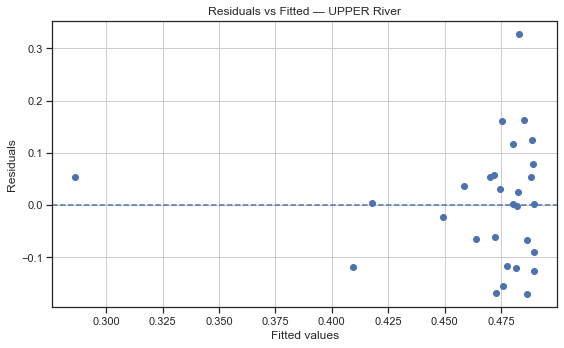

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


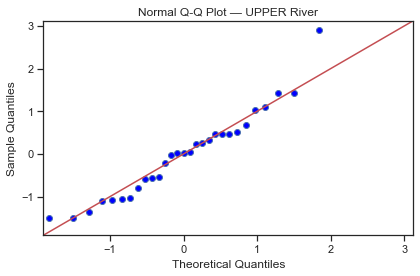

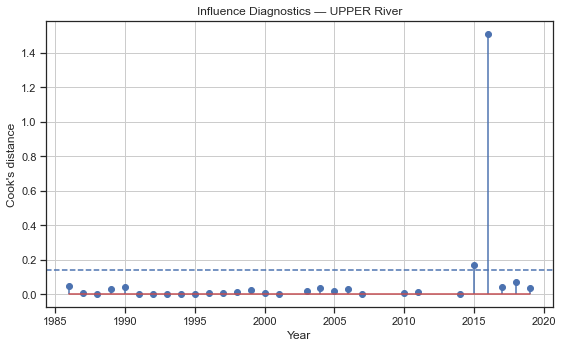


Potentially influential observations:
    Year    GM_Index  Growth_mm_per_day     Cooks
24  2015    7.815598           0.811220  0.169678
25  2016  155.181000           0.339175  1.509031


In [56]:
# ============================================================
# UPPER RIVER: MERGE DATA
# ============================================================

growth_abundance_upper = (
    growth_upper
    .merge(gm_upper[["Year", "GM_Index"]], on="Year", how="inner")
    .merge(temp_upper[["Year", "Mean_Temp"]], on="Year", how="inner")
    .sort_values("Year")
    .reset_index(drop=True)
)

print("\nMerged dataset — UPPER river")
print(growth_abundance_upper.head())
print("\nNumber of years (upper river):", len(growth_abundance_upper))

y = growth_abundance_upper["Growth_mm_per_day"]


# ============================================================
# SIMPLE REGRESSION: GROWTH VS GM INDEX
# ============================================================

X_gm = sm.add_constant(growth_abundance_upper["GM_Index"])
model_gm_upper = sm.OLS(y, X_gm).fit()

print("\nSimple regression: Growth vs GM Index — UPPER river")
print(model_gm_upper.summary())


# ============================================================
# SIMPLE REGRESSION: GROWTH VS TEMPERATURE
# ============================================================

X_temp = sm.add_constant(growth_abundance_upper["Mean_Temp"])
model_temp_upper = sm.OLS(y, X_temp).fit()

print("\nSimple regression: Growth vs Mean Temperature — UPPER river")
print(model_temp_upper.summary())


# ============================================================
# MULTIPLE REGRESSION: GROWTH ~ GM_INDEX + MEAN_TEMP
# ============================================================

X_multi = growth_abundance_upper[["GM_Index", "Mean_Temp"]]
X_multi = sm.add_constant(X_multi)

model_upper_multiple = sm.OLS(y, X_multi).fit()

print("\nMultiple regression — UPPER river")
print(model_upper_multiple.summary())


# ============================================================
# CHECK MULTICOLLINEARITY
# ============================================================

vif = pd.DataFrame()
vif["Variable"] = X_multi.columns
vif["VIF"] = [
    variance_inflation_factor(X_multi.values, i)
    for i in range(X_multi.shape[1])
]

print("\nVIF — UPPER river")
print(vif)


# ============================================================
# DIAGNOSTICS FOR SIMPLE GM MODEL
# ============================================================

growth_abundance_upper["Predicted_GM"] = model_gm_upper.fittedvalues
growth_abundance_upper["Residual_GM"] = model_gm_upper.resid

plt.figure(figsize=(8, 5))
plt.scatter(
    growth_abundance_upper["Predicted_GM"],
    growth_abundance_upper["Residual_GM"]
)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted — UPPER River")
plt.grid(True)
plt.tight_layout()
plt.show()

sm.qqplot(
    growth_abundance_upper["Residual_GM"],
    line="45",
    fit=True
)
plt.title("Normal Q-Q Plot — UPPER River")
plt.tight_layout()
plt.show()


# ============================================================
# COOK'S DISTANCE
# ============================================================

influence = model_gm_upper.get_influence()
cooks = influence.cooks_distance[0]

growth_abundance_upper["Cooks"] = cooks

threshold = 4 / len(growth_abundance_upper)

plt.figure(figsize=(8, 5))
plt.stem(growth_abundance_upper["Year"], cooks)
plt.axhline(threshold, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Cook's distance")
plt.title("Influence Diagnostics — UPPER River")
plt.grid(True)
plt.tight_layout()
plt.show()

influential = growth_abundance_upper[
    growth_abundance_upper["Cooks"] > threshold
]

print("\nPotentially influential observations:")
print(
    influential[
        ["Year", "GM_Index", "Growth_mm_per_day", "Cooks"]
    ]
)




# 6. Lower river: Growth versus abundance and temperature

In [57]:
# ============================================================
# MERGE DATA — LOWER RIVER
# ============================================================

growth_abundance_lower = (
    growth_lower
    .merge(gm_lower[["Year", "GM_Index"]], on="Year", how="inner")
    .merge(temp_lower[["Year", "Mean_Temp"]], on="Year", how="inner")
    .sort_values("Year")
    .reset_index(drop=True)
)

print("\nMerged dataset — LOWER river")
print(growth_abundance_lower.head())

print("\nNumber of years (lower river):",
      len(growth_abundance_lower))


# ============================================================
# SIMPLE REGRESSION:
# Growth vs GM Index — LOWER RIVER
# ============================================================

X_gm = sm.add_constant(
    growth_abundance_lower["GM_Index"]
)

y = growth_abundance_lower["Growth_mm_per_day"]

model_gm_lower = sm.OLS(y, X_gm).fit()

print("\nSimple regression: Growth vs GM Index — LOWER river")
print(model_gm_lower.summary())


# ============================================================
# SIMPLE REGRESSION:
# Growth vs Mean Temperature — LOWER RIVER
# ============================================================

X_temp = sm.add_constant(
    growth_abundance_lower["Mean_Temp"]
)

model_temp_lower = sm.OLS(y, X_temp).fit()

print("\nSimple regression: Growth vs Temperature — LOWER river")
print(model_temp_lower.summary())


# ============================================================
# MULTIPLE LINEAR REGRESSION — LOWER RIVER
# Growth ~ GM_Index + Mean_Temp
# ============================================================

X = growth_abundance_lower[
    ["GM_Index", "Mean_Temp"]
]

X = sm.add_constant(X)

model_lower_multiple = sm.OLS(y, X).fit()

print("\nMultiple regression — LOWER river")
print(model_lower_multiple.summary())


# ============================================================
# CHECK MULTICOLLINEARITY — LOWER RIVER
# ============================================================

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("\nVIF — LOWER river")
print(vif)


Merged dataset — LOWER river
   Year  Growth_mm_per_day  N_growth  N_DOY  Intercept   R_value  \
0  1986           0.273878       659     13   1.643211  0.480047   
1  1987           0.442438       769     12 -32.634525  0.687848   
2  1988           0.307467       381     12   1.091237  0.545923   
3  1989           0.564253       606     12 -65.426297  0.615466   
4  1990           0.312623       735     12 -14.266372  0.495870   

         P_value   GM_Index  Mean_Temp  
0   2.749978e-39   7.215578  23.434783  
1  7.815907e-109  11.008016  23.354167  
2   5.619235e-31   3.941590  26.062500  
3   1.893024e-64   7.327065  24.604167  
4   7.120558e-47  10.988923  24.116279  

Number of years (lower river): 35

Simple regression: Growth vs GM Index — LOWER river
                            OLS Regression Results                            
Dep. Variable:      Growth_mm_per_day   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:              

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)
/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)
/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)
